# <font color=blue> Actividad Operaciones Morfológicas y transformada de Hough</font>

Este notebook proporciona las bases necesarias para trabajar con la biblioteca OpenCV en Python para aplicar operaciones morfologicas y de la transformada de Hough.

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [59]:
img_path = "board.jpg"
image = cv2.imread(img_path)

## <font color="#F20C60">Metodos para dibujar en una imagen</font>

Se pueden dibujar elementos en una imagen como circulos y lineas las cuales nos ayudan a identificar elementos o resaltarlos.

### <font color="#770EB2">Lineas</font>

Dibuja una línea en una imagen.

### <font color=green> Sintaxis Básica </font>
``` python
cv2.line(image, pt1, pt2, color, tickness)
```

1. `image`: Imagen sobre la que se dibujará la línea.

2. `pt1 (tuple):` Punto inicial.

3.  `pt2 (tuple):` Punto final.

4.  `color (tuple):` Color de la línea en formato BGR.

5.  `thickness:` Grosor de la línea.

(-0.5, 639.5, 479.5, -0.5)

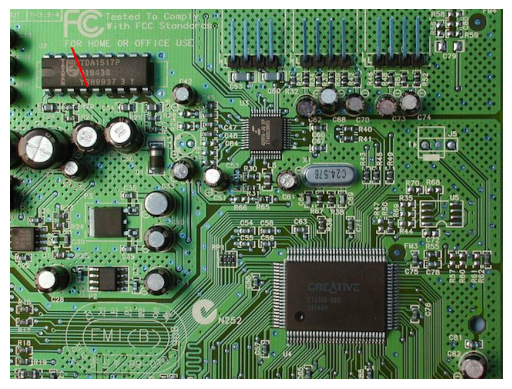

In [60]:
src = image.copy()
img_l = cv2.line(src, (80, 50), (100, 100), (255, 0, 0), 2)
plt.imshow(img_l)
plt.axis("off")

### <font color="#770EB2">Circulo</font>

Dibuja un círculo en una imagen.

### <font color=green> Sintaxis de la función </font>

``` python
cv2.circle(image, center, radius, color, tickness)
```



1. image (numpy array): Imagen sobre la que se dibujará el círculo.
2. center (tuple): Coordenadas del centro del círculo.
3. radius (int): Radio del círculo.
4. color (tuple): Color del círculo en formato BGR.
5. thickness (int): Grosor de la línea (-1 para rellenar el círculo).

(-0.5, 639.5, 479.5, -0.5)

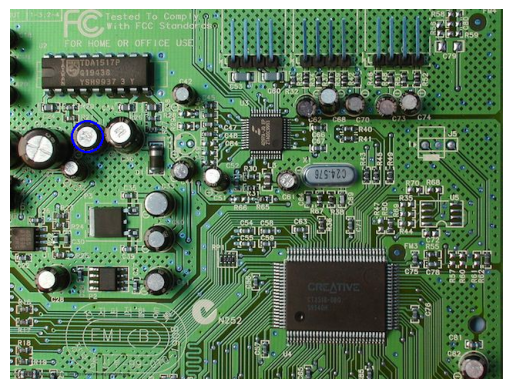

In [61]:
src = image.copy()
img_c = cv2.circle(src, (100, 165), 20, (0, 0, 255), 2)
plt.imshow(img_c)
plt.axis("off")

## <font color="#F20C60">Operaciones Morfologicas</font>

El procesamiento morfológico de imágenes es una herramienta para la
extracción de componentes de la imagen que sean útiles en la
representación y descripción de regiones.

En otras palabras, las operaciones morfológicas simplifican las imágenes y
conservan las principales características de forma de los objetos.

### <font color="#770EB2">Dilatación</font>

Aplica la dilatación morfológica en una imagen, expandiendo las regiones blancas.

### <font color=green> Sintaxis de la función </font>
``` python
cv2.dilate(src, kernel, iterations)
```

1. `src:` Imagen de entrada en escala de grises o binaria.
2. `kernel (numpy array):` Matriz estructural utilizada para la operación.
3. `iterations:` Número de veces que se aplica la dilatación.

(-0.5, 639.5, 479.5, -0.5)

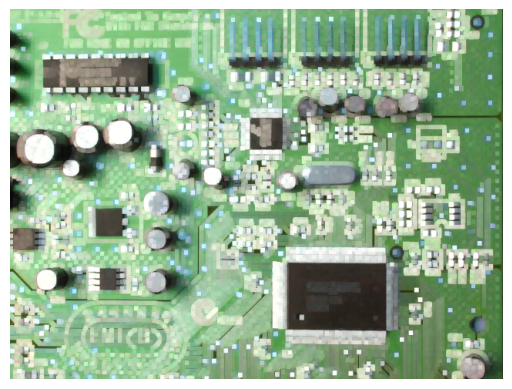

In [77]:
src = image.copy()
kernel = np.ones((5,5), np.uint8)
dilated = cv2.dilate(src, kernel, iterations=1)
plt.imshow(dilated)
plt.axis("off")

### <font color="#770EB2">Erosión</font>

Aplica la erosión morfológica en una imagen, reduciendo las regiones blancas.

### <font color=green> Sintaxis de la función </font>
``` python
cv2.erode(src, kernel, iterations)
```



1. `src:` Imagen de entrada en escala de grises o binaria.
2. `kernel (numpy array):` Matriz estructural utilizada para la operación.
3. `iterations:` Número de veces que se aplica la dilatación.

(-0.5, 639.5, 479.5, -0.5)

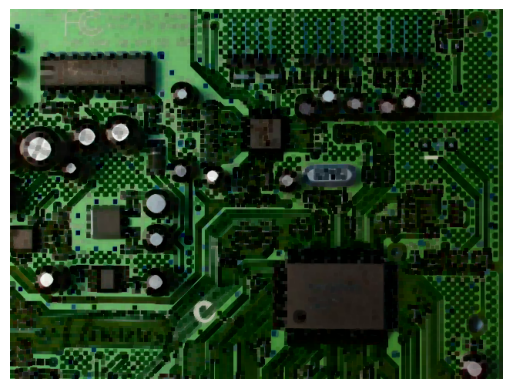

In [72]:
src = image.copy()
kernel = np.ones((5,5), np.uint8)
eroded = cv2.erode(src, kernel, iterations=1)
plt.imshow(eroded)
plt.axis("off")

### <font color="#770EB2">Avanzadas</font>

Aplica una operación morfológica avanzada combinando erosión y dilatación.

### <font color=green> Sintaxis de la función </font>
``` python
cv2.morphologyEx(src, op, kernel)
```

**Parámetros**

1. `src`: Imagen de entrada.
2. `op`: Tipo de operación morfológica.
3. `kernel`: Matriz estructural utilizada para la operación.

**Tipos de operación**
1. `cv2.MORPH_OPEN`: (Erosión seguida de dilatación, útil para eliminar ruido pequeño).
2. `cv2.MORPH_CLOSE:` (Dilatación seguida de erosión, útil para cerrar pequeños agujeros en un objeto).
3. `cv2.MORPH_GRADIENT:` (Diferencia entre dilatación y erosión, útil para detectar bordes).

(-0.5, 639.5, 479.5, -0.5)

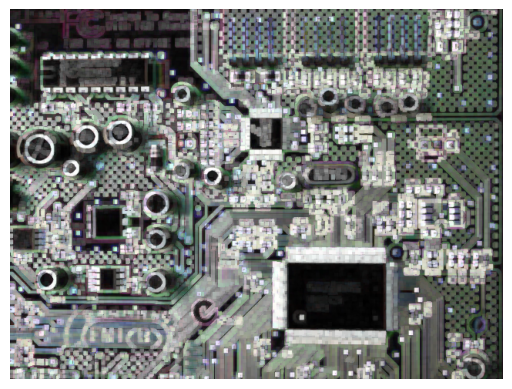

In [74]:
src = image.copy()
opened = cv2.morphologyEx(src, cv2.MORPH_GRADIENT, kernel)
plt.imshow(opened)
plt.axis("off")

## <font color="#F20C60">Momentos</font>

Calcula los momentos de una imagen, útiles para obtener propiedades geométricas como el centro de masa

### <font color=green> Ejemplo </font>
``` python
moments = cv2.moments(contour)
cx = int(moments['m10'] / moments['m00'])
cy = int(moments['m01'] / moments['m00'])
```

## <font color="#F20C60">Transformaciones de Hough</font>

La transformada de Hough es una técnica popular para detectar cualquier forma, siempre que se pueda representar esa forma matemáticamente. Este algoritmo puede detectar una forma determinada incluso si está rota o un poco distorsionada.

**Metodos de detección**
1. `cv2.HOUGH_GRADIENT`: Método estándar basado en gradientes para detectar círculos
2. `cv2.HOUGH_GRADIENT_ALT:` Variante mejorada del método basado en gradientes, más precisa pero más costosa computacionalmente.
3. `cv2.HOUGH_MULTI_SCALE:` Permite detectar círculos de diferentes tamaños automáticamente en una misma imagen.
4. `cv2.HOUGH_PROBABILISTIC:` Versión optimizada de la Transformada de Hough para líneas, usada en `cv2.HoughLines()`, devuelve segmentos de línea en lugar de ecuaciones.
5. `cv2.HOUGH_STANDAR:` Método tradicional para detectar líneas en cv2.HoughLines(), representando cada línea con (`rho, theta)`

### <font color="#770EB2">Hough Line</font>

Detecta líneas en una imagen usando la Transformada de Hough. Para mas información da clic [aqui](https://docs.opencv.org/3.4/d9/db0/tutorial_hough_lines.html).

### <font color=green> Sintaxis de la función </font>
``` python
line = cv2.HoughLines(src, rho, theta, threshold)
```

1. `src`: Imagen binaria de entrada.
2. `rho`: Resolución de la distancia en píxeles.
3. `theta`: Resolución del ángulo en radianes.
4. `threshold`: Número mínimo de intersecciones para detectar una línea.

### <font color="#770EB2">Hough Circulo</font>

Detecta círculos en una imagen usando la Transformada de Hough para círculos.Para mas información da clic [aqui](https://docs.opencv.org/4.x/da/d53/tutorial_py_houghcircles.html).

### <font color=green> Sintaxis de la función </font>
``` python
circle = cv2.HoughCircles(src, method, dp, minDist,param1, param2, minRadio, maxRadio)
```

**Parámetros**
1. `src`: Imagen de entrada en escala de grises.
2. `method`: Método de detección (generalmente `cv2.HOUGH_GRADIENT`).
3. `dp`: Relación de resolución del acumulador.
4. `minDist`: Distancia mínima entre los centros de los círculos detectados.
5. `param1`: Umbral del detector de bordes.
6. `param2`: Umbral para la detección de círculos.
7. `minRadio`: Minimo valor del radio.
8. `maxRadio`: Maximo valor del radio.

